In [1]:
import copy
import json
import os
import pandas as pd
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import torch
import warnings
warnings.filterwarnings("ignore")

def parse_pages(path: str = './pages/') -> pd.DataFrame:
    books_list = os.listdir(path)
    df_rows = []

    for book in tqdm(books_list):
        with open(path + book, 'r', encoding='utf-8') as f:
            for line in f:
                book_dict = json.loads(line)
                if 'error' not in book_dict:
                    df_rows.append(book_dict)

    return pd.DataFrame(df_rows)

dataframe = parse_pages('../pages/')
dataframe.sample(5)

  0%|          | 0/2333 [00:00<?, ?it/s]

,url,description,genres,tags,title,likes,rating,quality
14557,https://tl.rulate.ru/book/134159,Ты просыпаешься в сыром лесу. У тебя в руке — ...,"[боевик, литрпг, мистика, постапокалиптика, пр...","[быстрое развитие, выживание, главный герой им...",Выживание начинается с ножа,28,4.87 / 15 голосов,5 / 16 голосов
626,https://tl.rulate.ru/book/85319,"«Оттолкнув свет во тьму, я получил невероятную...","[боевик, приключения, сверхъестественное, траг...","[алхимия, быстрое развитие, главный герой жест...",Лорд славы,6,5 / 4 голоса,4.2 / 5 голосов
14488,https://tl.rulate.ru/book/128880,"Чжоу Тянь попал на континент Дулуо, заплатив з...","[боевик, боевые искусства, героическое фэнтези...","[главный герой мужчина, другой мир, мужчина пр...",Обожествление из мира духов,0,,
7584,https://tl.rulate.ru/book/75390,ВНИМАНИЕ!!!\n\nУ меня нет опыта в писательстве...,"[боевые искусства, героическое фэнтези, драма,...","[16+, 18+, актерское мастерство, воспоминания ...",Почему мои ученики монстры?,10,5 / 5 голосов,4.8 / 5 голосов
16341,https://tl.rulate.ru/book/129207,"Хорошие вещи приходят к тем, кто ждет. Дэмиен ...","[комедия, приключения, сверхъестественное, сён...","[главный герой мужчина, колледж, от слабого до...",Мой лучший друг - древний ужас,13,4.77 / 13 голосов,5 / 12 голосов


In [2]:
import re

dataframe['description'] = dataframe['description'].apply(lambda text: re.sub(r"[^a-zA-Zа-яА-Я0-9\s.,!?:;-]+", "", text))
dataframe['description'].describe()

count          22556
unique         21685
top       не найдено
freq             623
Name: description, dtype: object

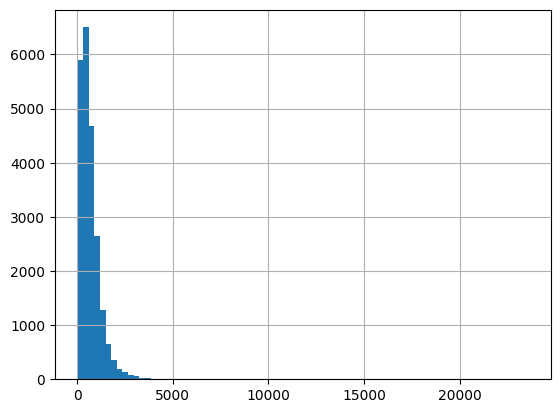

In [3]:
dataframe['description'].apply(len).hist(bins=80);

Отфильтруем слишком длинные описания

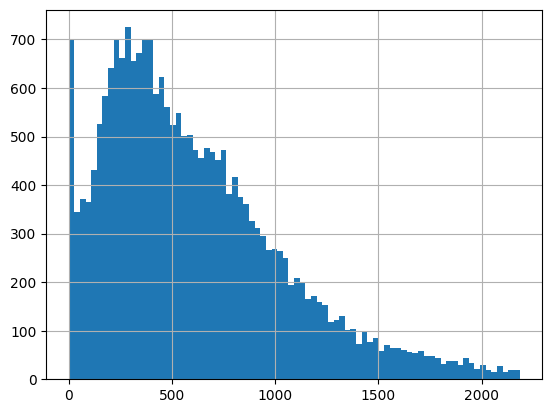

In [4]:
description_lens = dataframe['description'].apply(len)
dataframe = dataframe[description_lens < description_lens.quantile(0.98)]
dataframe['description'].apply(len).hist(bins=80);

Отфильтруем сэмплы без жанров, дублированные или с количеством слов в описании <= 5

In [5]:
df_filter = (
    dataframe['genres'].apply(lambda x: len(x) > 0) &
    dataframe['description'].apply(lambda x: len(x.split()) > 5) &
    ~dataframe['description'].duplicated(keep=False)
)
dataframe = dataframe[df_filter]
dataframe

,url,description,genres,tags,title,likes,rating,quality
0,https://tl.rulate.ru/book/127105,Шестой год Гарри начинается с ужасного лета у ...,[фанфик],"[волшебники, гарри поттер, главный герой сильн...",Гарри Поттер и принц Слизерина,1,,
1,https://tl.rulate.ru/book/127071,Возрожденный в игровом мире злодей-пушечное мя...,"[боевик, боевые искусства, героическое фэнтези...","[алхимия, всемогущий главный герой, главный ге...",Охотник на демонов: Я стал богом в мире охоты ...,7,4.2 / 5 голосов,4.2 / 5 голосов
3,https://tl.rulate.ru/book/135844,В 2025 году судьба преподнесла Артуру Беннетту...,"[приключения, фанфик]","[выживание, злой главный герой, от слабого до ...",Наруто: Тропа войны,3,3 / 2 голоса,5 / 1 голос
4,https://tl.rulate.ru/book/134398,Возможное продолжение последней книги серии о ...,[фанфик],"[альбус дамблдор, воландеморт, волшебники, вол...",Будущее Гарри,1,,
5,https://tl.rulate.ru/book/131202,"Сириус Блэк не умер, провалившись сквозь Вуаль...",[фанфик],"[временная петля, гарри поттер, магия, управле...",Гарри Поттер / Переломный момент,1,,
...,...,...,...,...,...,...,...,...
22551,https://tl.rulate.ru/book/104496,Юнь Му попадает в мир Одного Куска и заменяет ...,"[боевые искусства, приключения, фанфик]","[система, трансмиграция]","Ван Пис: Перерождение как Луффи, перевёрнутые ...",20,4.46 / 13 голосов,4 / 16 голосов
22552,https://tl.rulate.ru/book/92395,"Никто бы не подумал, что Лянь Цинсюэ, самая не...","[драма, комедия, романтика, сэйнэн, фэнтези, ш...","[второй шанс, красивая главная героиня, красив...","Богиня немного жалкая, я инвестировал в нее!",50,4.81 / 32 голоса,4.5 / 34 голоса
22553,https://tl.rulate.ru/book/115006,"В мире, где безраздельно правят ниндзя, ирония...","[боевик, повседневность, приключения, сверхъес...","[амбициозный главный герой, главный герой мужч...",Почему При Вторжении в Параллельные Миры Ниндз...,7,5 / 6 голосов,5 / 6 голосов
22554,https://tl.rulate.ru/book/115765,Гг переселяется в мир Наруто в теле гражданско...,"[боевые искусства, приключения, фанфик, фэнтези]","[красивые женщины, от слабого до сильного, пер...",Наруто: Возрождение с Гура Гура но Ми,5,3 / 3 голоса,4.5 / 2 голоса


Подсчитаем количество появлений каждого жанра

In [6]:
from collections import Counter

genres_counts = Counter()

for genres in dataframe['genres']:
    genres_counts.update(genres)
genres_counts

Counter({'приключения': 10760,
         'фэнтези': 10500,
         'романтика': 7167,
         'боевик': 6882,
         'фанфик': 5754,
         'боевые искусства': 5308,
         'фантастика': 4873,
         'комедия': 4681,
         'повседневность': 3719,
         'драма': 3641,
         'сверхъестественное': 3474,
         'мистика': 2466,
         'героическое фэнтези': 2331,
         'научная фантастика': 1912,
         'психология': 1716,
         'история': 1563,
         'школа': 1520,
         'сёнэн': 1145,
         'дзёсэй': 999,
         'трагедия': 882,
         'сёдзё': 836,
         'сянься (XianXia)': 709,
         'литрпг': 671,
         'постапокалиптика': 609,
         'ужасы': 588,
         'уся (wuxia)': 505,
         'детектив': 489,
         'сюаньхуа': 466,
         'триллер': 435,
         'городское фэнтези': 420,
         'мелодрама': 373,
         'сэйнэн': 269,
         'самурайский боевик': 247,
         'сюаньхуань': 230,
         'меха': 134,
         '

В жанрах кодомо и махо-сёдзе крайне малое количество примеров + сгенерировать что-то четко к ним относящееся сложно - выбрасываем, остальные жанры объединим в более крупные смысловые кластеры

In [7]:
genre_map = {
    "фэнтези": "фэнтези",
    "героическое фэнтези": "фэнтези",
    "городское фэнтези": "фэнтези",
    "фантастика": "фантастика",
    "научная фантастика": "фантастика",
    "киберпанк": "фантастика",
    "постапокалиптика": "фантастика",
    "меха": "фантастика",
    "боевые искусства": "боевые искусства/сянься",
    "уся (wuxia)": "боевые искусства/сянься",
    "сянься (XianXia)": "боевые искусства/сянься",
    "сюаньхуа": "боевые искусства/сянься",
    "сюаньхуань": "боевые искусства/сянься",
    "романтика": "романтика/драма",
    "драма": "романтика/драма",
    "мелодрама": "романтика/драма",
    "трагедия": "романтика/драма",
    "мистика": "мистика/ужасы",
    "сверхъестественное": "мистика/ужасы",
    "ужасы": "мистика/ужасы",
    "школа": "школа/повседневность",
    "повседневность": "школа/повседневность",
    "боевик": "боевик",
    "самурайский боевик": "боевик",
    "приключения": "приключения",
    "комедия": "комедия",
    "фанфик": "фанфик",
    "психология": "психология",
    "история": "история",
    "сёнэн": "сёнэн",
    "сёдзё": "сёдзё",
    "дзёсэй": "дзёсэй",
    "сэйнэн": "сэйнэн",
    "литрпг": "литрпг",
    "детектив": "детектив",
    "триллер": "триллер",
    "спорт": "спорт"
}


In [8]:
def drop_genres(sample_list: list[str], columns_to_drop: list[str], genre_map: dict[str, str]) -> list[str]:
    remain_list = [item for item in sample_list if item not in columns_to_drop]
    remain_list = [genre_map[item] for item in remain_list if item in genre_map]
    return remain_list


columns_to_drop = ['кодомо', 'махо-сёдзё']
dataframe['genres'] = dataframe['genres'].apply(lambda x: drop_genres(x, columns_to_drop, genre_map))
dataframe = dataframe[dataframe['genres'].apply(len) > 0].reset_index(drop=True)

Бинаризуем лейблы и делаем стратификацию val и test

In [9]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer

binarizer = MultiLabelBinarizer()
y = binarizer.fit_transform(dataframe['genres'])
X = dataframe

splitter1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter1.split(X, y))

X_trainval, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_trainval, y_val = y[train_idx], y[val_idx]

splitter2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train2_idx, test_idx = next(splitter2.split(X_trainval, y_trainval))

X_train, X_test = X_trainval.iloc[train2_idx], X_trainval.iloc[test_idx]
y_train, y_test = y_trainval[train2_idx], y_trainval[test_idx]

id2label = {num: label for num, label in enumerate(binarizer.classes_)}
label2id = {value: key for key, value in id2label.items()}

print(id2label)

{0: 'боевик', 1: 'боевые искусства/сянься', 2: 'детектив', 3: 'дзёсэй', 4: 'история', 5: 'комедия', 6: 'литрпг', 7: 'мистика/ужасы', 8: 'приключения', 9: 'психология', 10: 'романтика/драма', 11: 'спорт', 12: 'сэйнэн', 13: 'сёдзё', 14: 'сёнэн', 15: 'триллер', 16: 'фантастика', 17: 'фанфик', 18: 'фэнтези', 19: 'школа/повседневность'}


In [10]:
from transformers import PreTrainedTokenizer
from typing import Any

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model_name = 'sergeyzh/BERTA'
max_length = 512

def map_sample(sample: dict[str, Any], tokenizer: PreTrainedTokenizer, binarizer: MultiLabelBinarizer) -> dict[str, Any]:
    tokenized_sample = tokenizer(
        'categorize_entailment: ' + sample['description'],
        truncation=True
    )

    label_vector = np.zeros(len(binarizer.classes_), dtype=int)
    for genre in sample["genres"]:
        if genre in binarizer.classes_:
            label_vector[binarizer.classes_.tolist().index(genre)] = 1

    tokenized_sample["labels"] = label_vector.tolist()
    return tokenized_sample


In [11]:
from collections import Counter

genres_counts2 = Counter()

for genres in dataframe['genres']:
    genres_counts2.update(genres)
genres_counts2

Counter({'фэнтези': 13251,
         'романтика/драма': 12063,
         'приключения': 10760,
         'фантастика': 7661,
         'боевые искусства/сянься': 7218,
         'боевик': 7129,
         'мистика/ужасы': 6528,
         'фанфик': 5754,
         'школа/повседневность': 5239,
         'комедия': 4681,
         'психология': 1716,
         'история': 1563,
         'сёнэн': 1145,
         'дзёсэй': 999,
         'сёдзё': 836,
         'литрпг': 671,
         'детектив': 489,
         'триллер': 435,
         'сэйнэн': 269,
         'спорт': 129})

In [12]:
import numpy as np
from transformers import AutoTokenizer
from datasets import Dataset

train_dataset = Dataset.from_pandas(X_train[['description', 'genres']])
val_dataset = Dataset.from_pandas(X_val[['description', 'genres']])
test_dataset = Dataset.from_pandas(X_test[['description', 'genres']])

tokenizer = AutoTokenizer.from_pretrained(model_name, token=os.environ['HUGGINGFACE_HUB_TOKEN'])

train_gemma_dataset = train_dataset.map(lambda x: map_sample(x, tokenizer, binarizer))
val_gemma_dataset = val_dataset.map(lambda x: map_sample(x, tokenizer, binarizer))
test_gemma_dataset = test_dataset.map(lambda x: map_sample(x, tokenizer, binarizer))

train_gemma_dataset = train_gemma_dataset.remove_columns(['description', 'genres', '__index_level_0__'])
val_gemma_dataset = val_gemma_dataset.remove_columns(['description', 'genres', '__index_level_0__'])
test_gemma_dataset = test_gemma_dataset.remove_columns(['description', 'genres', '__index_level_0__'])

Map:   0%|          | 0/13723 [00:00<?, ? examples/s]

Map:   0%|          | 0/3852 [00:00<?, ? examples/s]

Map:   0%|          | 0/1541 [00:00<?, ? examples/s]

Т.к. в классах наблюдается сильный дисбаланс, для обучения модели будет использоваться Focal Loss с $\gamma$ = 2


In [13]:
from transformers import AutoModel
import torch.nn as nn
import torchmetrics

class BertaClassifier(nn.Module):
    def __init__(self, model_name: str, num_labels: int):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(model_name, token=os.environ['HUGGINGFACE_HUB_TOKEN'])
        self.classification_head = nn.Sequential(
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(self.backbone.config.hidden_size, num_labels),
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        backbone_embed = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = backbone_embed.last_hidden_state
        expanded_attention_mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * expanded_attention_mask, dim=1)
        sum_mask = torch.clamp(expanded_attention_mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask
        logits = self.classification_head(mean_pooled)
        return logits

    def predict(self, input_ids: torch.Tensor, attention_mask: torch.Tensor, thresholds: torch.Tensor):
        with torch.inference_mode():
            logits = self(input_ids, attention_mask)
            probas = nn.functional.sigmoid(logits)
            preds = probas >= thresholds
        return probas, preds


class FocalLoss(nn.Module):
    def __init__(self, pos_weight: torch.Tensor, alpha: float = 1.0, gamma: float = 2.0):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits: torch.Tensor, labels: torch.Tensor):
        ce_loss = nn.functional.binary_cross_entropy_with_logits(logits, labels, reduction="none", pos_weight=self.pos_weight)
        probas = nn.functional.sigmoid(logits)
        pt = probas * labels + (1 - probas) * (1 - labels)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()


def train_epoch(model: BertaClassifier, train_dataloader: DataLoader, loss_fn: Any, optimizer: Any, scheduler: Any, batch_accumulation: int = 16) -> float:
    mean_loss = 0

    batch_count = len(train_dataloader)
    current_accum_batches_count = 0
    model.train()
    for i, batch in tqdm(enumerate(train_dataloader), total=batch_count):
        logits = model(
            input_ids=batch['input_ids'].to(DEVICE, non_blocking=True),
            attention_mask=batch['attention_mask'].to(DEVICE, non_blocking=True))
        loss = loss_fn(logits, batch['labels'].to(DEVICE, non_blocking=True).float())
        mean_loss += loss.item()
        loss /= batch_accumulation
        loss.backward()
        current_accum_batches_count += 1

        if (i+1) % batch_accumulation == 0 or i+1 == batch_count:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
    scheduler.step()
    mean_loss /= len(train_dataloader)
    return mean_loss


def evaluate_epoch(model: BertaClassifier, val_dataloader: DataLoader, loss_fn: Any) -> tuple[float, dict[str, torch.Tensor]]:
    mean_loss = 0
    metrics = torchmetrics.MetricCollection({
        "f1-macro": torchmetrics.F1Score(task="multilabel", num_labels=len(id2label), average="macro"),
        "f1-micro": torchmetrics.F1Score(task="multilabel", num_labels=len(id2label), average="micro"),
        "hamming_micro": torchmetrics.HammingDistance(task="multilabel", num_labels=len(id2label), average="micro"),
        "jaccard": torchmetrics.JaccardIndex(task="multilabel", num_labels=len(id2label), average="macro"),
    }).to(DEVICE)


    model.eval()
    with torch.inference_mode():
        for batch in tqdm(val_dataloader, total=len(val_dataloader)):
            logits = model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))

            val_loss = loss_fn(logits, batch['labels'].to(DEVICE, non_blocking=True).float(),)
            probas = torch.nn.functional.sigmoid(logits)

            metrics.update(probas, batch['labels'].to(DEVICE, non_blocking=True))
            mean_loss += val_loss.item()
    mean_loss /= len(val_dataloader)
    return mean_loss, {k: v.detach().cpu().item() for k, v in metrics.compute().items()}



In [14]:
from transformers import DataCollatorWithPadding

def train_model(
        model: BertaClassifier,
        optimizer: Any,
        scheduler: Any,
        loss: Any,
        params: dict[str, Any],
        train_dataloader: DataLoader,
        val_dataloader: DataLoader):

    best_val_f1 = -1e+9
    best_model = None
    best_epoch = 0

    for epoch in tqdm(range(params['epochs'])):
        train_loss = train_epoch(
            model=model,
            train_dataloader=train_dataloader,
            loss_fn=loss,
            optimizer=optimizer,
            scheduler=scheduler,
            batch_accumulation=params['batch_accumulation'])

        val_loss, val_metrics = evaluate_epoch(model=model, val_dataloader=val_dataloader, loss_fn=loss)

        print(f'epoch {epoch+1}: train_loss/{train_loss}, val_loss/{val_loss}')
        print(val_metrics)
        if val_metrics['f1-macro'] > best_val_f1:
            best_model = copy.deepcopy(model)
            best_val_f1 = val_metrics['f1-macro']
            best_epoch = epoch+1
        torch.cuda.empty_cache()
    exp_num = params['num']
    torch.save(best_model, f'best_model_{exp_num}.pt')
    print(f"epoch {best_epoch}/best_val_f1: ", best_val_f1)

In [24]:
import gc

class_frequency = y_train.mean(axis=0)
pos_weight = torch.tensor((1 - class_frequency) / (class_frequency + 1e-9), dtype=torch.float)
pos_weight = pos_weight.clamp(max=50).to(DEVICE)

params = {
    'train_batch_size': 8,
    'val_batch_size': 32,
    'batch_accumulation': 16,
    'lr': 5e-5,
    'weight_decay': 2e-2,
    'T_max': 14,
    'eta_min': 1e-5,
    'epochs': 10,
    'num': 1
}

model = BertaClassifier(model_name=model_name, num_labels=len(id2label)).to(DEVICE)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=params['T_max'], eta_min=params['eta_min'])
loss = FocalLoss(pos_weight=pos_weight).to(DEVICE)

collate_fn = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    train_gemma_dataset,
    batch_size=params['train_batch_size'],
    shuffle=True,
    pin_memory=True,
    collate_fn=collate_fn,
    num_workers=0)

val_dataloader = DataLoader(
    val_gemma_dataset,
    batch_size=params['val_batch_size'],
    shuffle=False,
    pin_memory=True,
    collate_fn=collate_fn,
    num_workers=0)

train_model(model, optimizer, scheduler, loss, params, train_dataloader, val_dataloader)
del model, optimizer, scheduler, loss
torch.cuda.empty_cache()
gc.collect();

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1716 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

epoch 1: train_loss/0.2396994209164506, val_loss/0.21848029440099542
{'f1-macro': 0.3907538056373596, 'f1-micro': 0.4981415867805481, 'hamming_micro': 0.3032061457633972, 'jaccard': 0.26976829767227173}


  0%|          | 0/1716 [00:00<?, ?it/s]

...

  0%|          | 0/121 [00:00<?, ?it/s]

epoch 9: train_loss/0.1085470487170425, val_loss/0.3999131511558186
{'f1-macro': 0.43853867053985596, 'f1-micro': 0.5806111693382263, 'hamming_micro': 0.1964823603630066, 'jaccard': 0.30493128299713135}


  0%|          | 0/1716 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

epoch 10: train_loss/0.10053617776195695, val_loss/0.44311033484856943
{'f1-macro': 0.43517810106277466, 'f1-micro': 0.5846563577651978, 'hamming_micro': 0.19016093015670776, 'jaccard': 0.3023568391799927}
epoch 6/best_val_f1:  0.4412689208984375


In [25]:
def fit_threshold(logits: torch.Tensor, y: torch.Tensor):
    prob = torch.sigmoid(logits)
    threshold_array = torch.zeros(prob.shape[1])
    precision_recall = torchmetrics.classification.precision_recall_curve.PrecisionRecallCurve(task='binary', num_labels=len(id2label))
    for class_ in range(prob.shape[1]):
        precision, recall,threshold = precision_recall(prob[:,class_], y[:,class_])
        f1 = 2 * precision[1:] * recall[1:]/(precision[1:] + recall[1:] + 1e-9)
        threshold_array[class_] = threshold[np.nanargmax(f1)]
    return threshold_array

all_logits = []
model = torch.load('best_model_1.pt', weights_only=False).to(DEVICE)
model.eval()
with torch.inference_mode():
    for batch in tqdm(val_dataloader):
        logits = model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
        all_logits.append(logits.detach().cpu())

all_logits = torch.cat(all_logits, dim=0)

thresholds = fit_threshold(all_logits, torch.tensor(y_val))

  0%|          | 0/121 [00:00<?, ?it/s]

In [32]:
from torchmetrics.functional import f1_score, jaccard_index, hamming_distance

probs_val = torch.sigmoid(all_logits)
preds_val = (probs_val >= thresholds)

print("val macro_f1:", f1_score(torch.tensor(y_val), preds_val, task='multilabel', num_labels=len(id2label), average="macro", zero_division=0))
print("val micro_f1:", f1_score(torch.tensor(y_val), preds_val, task='multilabel', num_labels=len(id2label), average="micro", zero_division=0))
print("val jaccard:", jaccard_index(torch.tensor(y_val), preds_val,task='multilabel', num_labels=len(id2label), average="macro", zero_division=0))
print("val hamming:", hamming_distance(torch.tensor(y_val), preds_val, task='multilabel', average='macro',num_labels=len(id2label)))

val macro_f1: tensor(0.4637)
val micro_f1: tensor(0.6125)
val jaccard: tensor(0.3263)
val hamming: tensor(0.1955)


In [27]:
from sklearn.metrics._classification import classification_report
print(classification_report(torch.tensor(y_val), preds_val, target_names=binarizer.classes_))

                         precision    recall  f1-score   support

                 боевик       0.52      0.88      0.66      1400
боевые искусства/сянься       0.63      0.67      0.65      1201
               детектив       0.23      0.36      0.28        98
                 дзёсэй       0.33      0.81      0.47       200
                история       0.36      0.32      0.34       313
                комедия       0.41      0.54      0.47       936
                 литрпг       0.23      0.28      0.25       134
          мистика/ужасы       0.34      0.76      0.47       973
            приключения       0.68      0.94      0.79      2152
             психология       0.17      0.38      0.24       343
        романтика/драма       0.60      0.82      0.69      1754
                  спорт       0.56      0.58      0.57        26
                 сэйнэн       0.09      0.11      0.10        54
                  сёдзё       0.28      0.53      0.37       167
                  сёнэн 

In [33]:
all_logits = []
test_dataloader = DataLoader(
    test_gemma_dataset,
    batch_size=params['val_batch_size'],
    shuffle=False,
    pin_memory=True,
    collate_fn=collate_fn,
    num_workers=0)

with torch.inference_mode():
    for batch in tqdm(test_dataloader):
        logits = model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE))
        all_logits.append(logits.detach().cpu())

all_logits = torch.cat(all_logits, dim=0)

  0%|          | 0/49 [00:00<?, ?it/s]

In [36]:
probs_test = torch.sigmoid(all_logits)
preds_test = (probs_test >= thresholds)

print("test macro_f1:", f1_score(torch.tensor(y_test), preds_test, task='multilabel', num_labels=len(id2label), average="macro", zero_division=0))
print("test micro_f1:", f1_score(torch.tensor(y_test), preds_test, task='multilabel', num_labels=len(id2label), average="micro", zero_division=0))
print("test jaccard:", jaccard_index(torch.tensor(y_test), preds_test,task='multilabel', num_labels=len(id2label), average="macro", zero_division=0))
print("test hamming:", hamming_distance(torch.tensor(y_test), preds_test, task='multilabel', average='macro',num_labels=len(id2label)))

test macro_f1: tensor(0.4698)
test micro_f1: tensor(0.6195)
test jaccard: tensor(0.3309)
test hamming: tensor(0.1912)


In [37]:
torch.save(thresholds, 'thresholds.pt')
dataframe.to_csv('book_dataset.csv')